In [45]:
!pip install numpy==2.2.0
!mamba install pandas==2.2.3
!mamba install scikit-learn

!pip install matplotlib==3.9.3
!pip install geopandas
!pip install contextily

!mamba install shapely
!mamba install rasterio
!mamba install pyproj
!mamba install pyogrio

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas==2.2.3, scikit-learn, shapely, rasterio, pyproj, pyogrio
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.3997000000029804 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas==2.2.3, scikit-learn, shapely, rasterio, pyproj, pyogrio
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.9295 seconds
All requested packages already installed.
mambajs 0.19.13

Process pip requirements ...

Requirement matplotlib already handled by conda/micromamba/mamba.
mambajs 0.19.13

Process pip requirements ...

Requirement geopandas already satisfied.
mambajs 0.19.13

Process pip requirements ...

Requirement contextily already s

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

# geographical tools
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

In [82]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [139]:
# Write a function that plots clustered locations and overlays them on a basemap.
from pyproj import Transformer
from shapely.geometry import Point

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    # 1. Back to basics: Convert EVERYTHING to numeric, non-numeric becomes NaN
    df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
    df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
    
    # 2. Drop any row that has a NaN in either coordinate
    df = df.dropna(subset=['Latitude', 'Longitude'])
    
    # 3. Filter for REAL Canadian coordinates
    # Latitude: 41 to 83 degrees | Longitude: -141 to -52 degrees
    # This eliminates 0,0 or placeholder coordinates that break the math
    df = df[
        (df['Latitude'] > 40) & (df['Latitude'] < 84) & 
        (df['Longitude'] > -142) & (df['Longitude'] < -50)
    ]
    
    # 4. Rebuild the GeoDataFrame from scratch
    gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), 
        crs="EPSG:4326"
    )
    
    # 5. Transform to 3857 (Meters)
    gdf = gdf.to_crs(epsg=3857)
    
    # 6. Check the Bounds
    print("--- BOUNDS CHECK ---")
    print(gdf.total_bounds)

    # Step 3: VERIFY IMMEDIATELY
    print("--- COORDINATE CHECK ---")
    print(f"Current CRS: {gdf.crs}")
    print(f"First Geometry: {gdf.geometry.iloc[0]}")
    
    # Check the bounds - if they are small (like -100, 50), it FAILED.
    # If they are large (like -1e7, 6e6), it WORKED.
    print(f"Bounds: {gdf.total_bounds}")

    
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    gdf = gdf.copy()
    gdf['geometry'] = gdf['geometry'].apply(lambda geom: Point(transformer.transform(geom.x, geom.y)))
    gdf = gdf.set_crs("EPSG:3857", allow_override=True)
    
    print(gdf.crs)
    print(gdf.total_bounds)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate clustered from noise points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot points
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise', zorder=3)
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6, zorder=3)
    
    # Save limits before basemap resets them
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 1. Plot EVERYTHING ELSE in light grey first (The "Background")
    # This includes noise (-1) and all other clusters
    #background_data = gdf[gdf['Cluster'] != 30]
    #background_data.plot(ax=ax, color='lightgrey', markersize=10, alpha=0.5, zorder=2, label='Other Museums')
    
    # 2. Plot ONLY Cluster 0 in a bold color (The "Highlight")
    #highlight_data = gdf[gdf['Cluster'] == 30]
    #highlight_data.plot(ax=ax, color='blue', markersize=50, edgecolors='black', linewidth=1, zorder=3, label='Cluster 0')
    
    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=4, zorder=1)
    
    # Restore data extent
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # Format plot
    plt.title('Museums Clustered by Proximity')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [83]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")
df_original = df

In [84]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [85]:
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [86]:
df = df[df.ODCAF_Facility_Type == 'museum']
df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
museum    1938
Name: count, dtype: int64

In [87]:
df = df[['Latitude', 'Longitude']]

In [88]:
# Remove observations with no coordinates 
df = df[df.Latitude!='..']

# Convert to float
df[['Latitude','Longitude']] = df[['Latitude','Longitude']].astype('float')

In [89]:
# In this case we know how to scale the coordinates. Using standardization would be an error becaues we aren't using the full range of the lat/lng coordinates.
# Since latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees, the correct scaling is to double the longitude coordinates (or half the Latitudes)
coords_scaled = df.copy()
coords_scaled["Latitude"] = 2*coords_scaled["Latitude"]

In [90]:
# 3. Configure DBSCAN
# Note: eps for Haversine is in radians. 
# To get 1km radius: 1 / 6371 (Earth's radius in km)
min_samples=3
eps=1.0
metric='euclidean' # distance measure 

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)
df['Cluster'] = dbscan.labels_

In [91]:
df['Cluster'] = dbscan.fit_predict(coords_scaled)  # Assign the cluster labels

# Display the size of each cluster
df['Cluster'].value_counts()

Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 24      6
 18      6
 28      6
 26      6
 14      6
 5       6
 22      4
 9       4
 13      4
 30      3
 31      3
 29      3
 0       3
 25      3
 23      3
 21      3
 17      3
 32      3
Name: count, dtype: int64

In [92]:
df

,Latitude,Longitude,Cluster
1,55.264551,-127.642812,0
2,45.963283,-66.641902,1
8,49.176354,-123.112783,2
13,49.261938,-123.151123,2
15,49.889559,-97.235744,3
...,...,...,...
7934,43.183090,-79.224564,4
7936,43.690022,-79.476208,4
7940,43.857692,-79.361940,4
7968,48.422420,-123.343553,2


In [93]:
# Force conversion to numeric - this turns '..' into NaN automatically
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')


In [94]:
# Drop rows where coordinates are missing
df = df.dropna(subset=['Latitude', 'Longitude'])

In [ ]:
# 1. Back to basics: Convert EVERYTHING to numeric, non-numeric becomes NaN
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 2. Drop any row that has a NaN in either coordinate
df = df.dropna(subset=['Latitude', 'Longitude'])

# 3. Filter for REAL Canadian coordinates
# Latitude: 41 to 83 degrees | Longitude: -141 to -52 degrees
# This eliminates 0,0 or placeholder coordinates that break the math
df = df[
    (df['Latitude'] > 40) & (df['Latitude'] < 84) & 
    (df['Longitude'] > -142) & (df['Longitude'] < -50)
]

# 4. Rebuild the GeoDataFrame from scratch
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), 
    crs="EPSG:4326"
)

# 5. Transform to 3857 (Meters)
gdf = gdf.to_crs(epsg=3857)

# 6. Check the Bounds
print("--- BOUNDS CHECK ---")
print(gdf.total_bounds)



In [131]:
# Step 3: VERIFY IMMEDIATELY
print("--- COORDINATE CHECK ---")
print(f"Current CRS: {gdf.crs}")
print(f"First Geometry: {gdf.geometry.iloc[0]}")

# Check the bounds - if they are small (like -100, 50), it FAILED.
# If they are large (like -1e7, 6e6), it WORKED.
print(f"Bounds: {gdf.total_bounds}")

--- COORDINATE CHECK ---
Current CRS: EPSG:4326
First Geometry: POINT (-127.6428124 55.2645508)
Bounds: [-139.4316955    41.7372093   -52.6842171    67.02961255]


EPSG:3857
[-15521465.34350277   5121695.59478093  -5864780.22041428
  10164500.49331969]


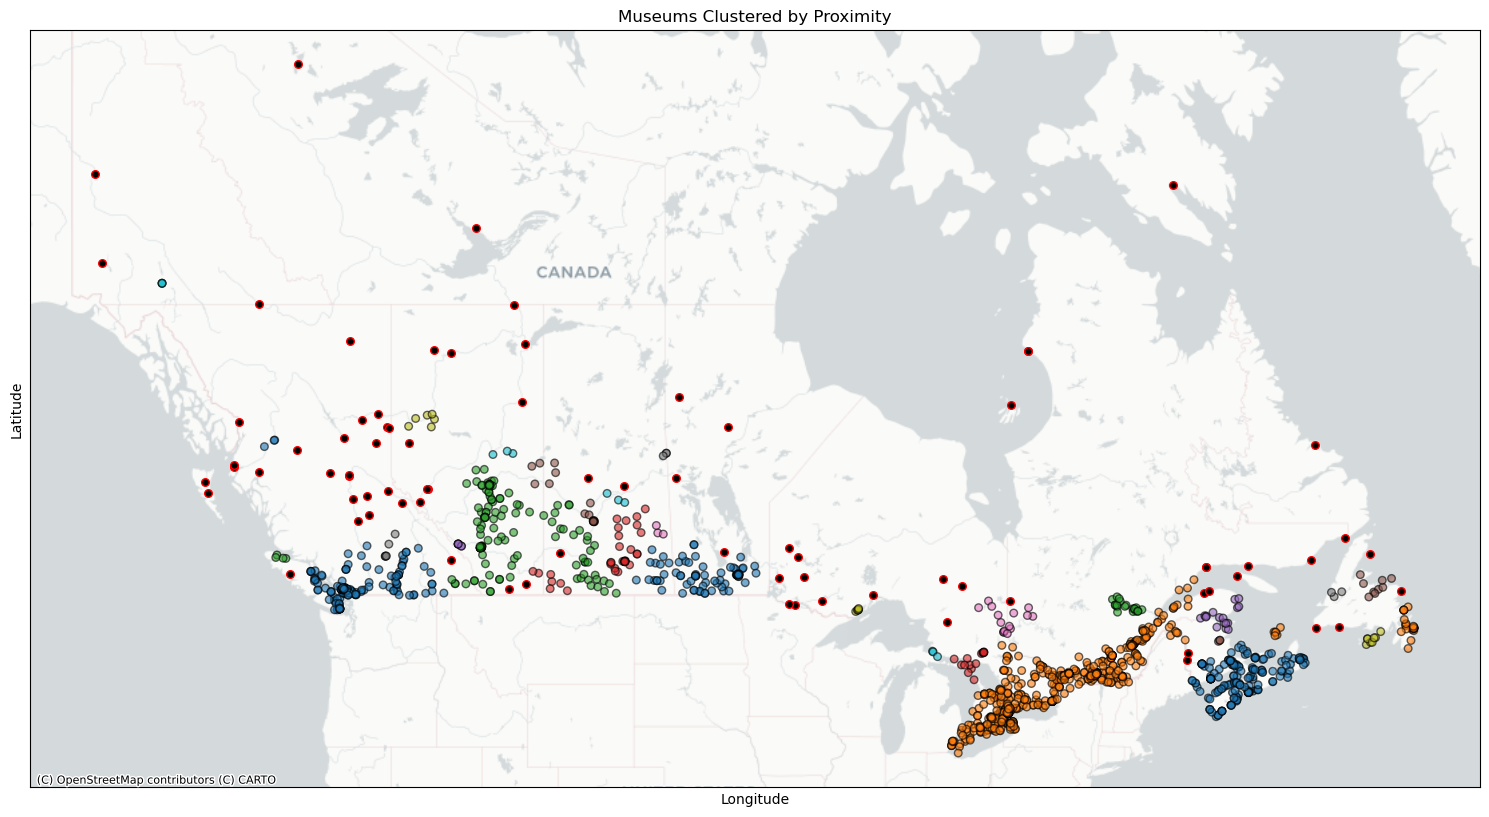

In [132]:
from pyproj import Transformer
from shapely.geometry import Point

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
gdf = gdf.copy()
gdf['geometry'] = gdf['geometry'].apply(lambda geom: Point(transformer.transform(geom.x, geom.y)))
gdf = gdf.set_crs("EPSG:3857", allow_override=True)

print(gdf.crs)
print(gdf.total_bounds)

# Create the plot
fig, ax = plt.subplots(figsize=(15, 10))

# Separate clustered from noise points
non_noise = gdf[gdf['Cluster'] != -1]
noise = gdf[gdf['Cluster'] == -1]

# Plot points
noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise', zorder=3)
non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6, zorder=3)

# Save limits before basemap resets them
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 1. Plot EVERYTHING ELSE in light grey first (The "Background")
# This includes noise (-1) and all other clusters
#background_data = gdf[gdf['Cluster'] != 30]
#background_data.plot(ax=ax, color='lightgrey', markersize=10, alpha=0.5, zorder=2, label='Other Museums')

# 2. Plot ONLY Cluster 0 in a bold color (The "Highlight")
#highlight_data = gdf[gdf['Cluster'] == 30]
#highlight_data.plot(ax=ax, color='blue', markersize=50, edgecolors='black', linewidth=1, zorder=3, label='Cluster 0')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=4, zorder=1)

# Restore data extent
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Format plot
plt.title('Museums Clustered by Proximity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

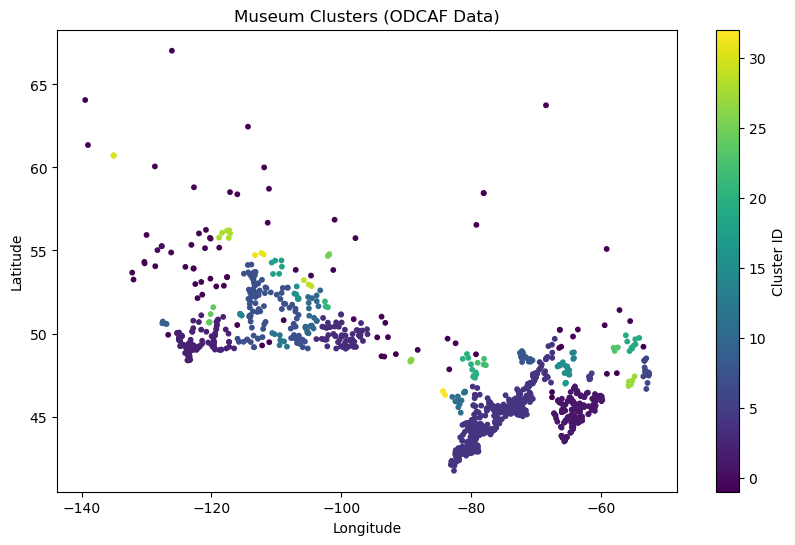

In [133]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Cluster'], cmap='viridis', s=10)
plt.title('Museum Clusters (ODCAF Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster ID')
plt.show()

In [118]:
print(df.columns)

Index(['Latitude', 'Longitude', 'Cluster'], dtype='object')


In [119]:
# Create a new GeoDataFrame that includes the original text data
# This joins based on the index (row numbers)
gdf = gdf.join(df_original[['Facility_Name', 'City', 'Prov_Terr']])


In [120]:
print(gdf.columns)

Index(['Latitude', 'Longitude', 'Cluster', 'geometry', 'Facility_Name', 'City',
       'Prov_Terr'],
      dtype='object')


In [121]:
gdf

,Latitude,Longitude,Cluster,geometry,Facility_Name,City,Prov_Terr
1,55.264551,-127.642812,0,POINT (-14209132.88 7413380.246),'Ksan Historical Village & Museum,hazelton,bc
2,45.963283,-66.641902,1,POINT (-7418542.563 5774467.246),'School Days' Museum,fredericton,nb
8,49.176354,-123.112783,2,POINT (-13704852.314 6304838.161),12 Service Battalion Museum,richmond,bc
13,49.261938,-123.151123,2,POINT (-13709120.303 6319424.231),15th Field Artillery Regiment Museum And Archives,vancouver,bc
15,49.889559,-97.235744,3,POINT (-10824233.505 6427171.251),17 Wing Heritage Collection,winnipeg,mb
...,...,...,...,...,...,...,...
7934,43.183090,-79.224564,4,POINT (-8819238.134 5339881.638),YMCA of Niagara Children's Discovery Centre,st catharines,on
7936,43.690022,-79.476208,4,POINT (-8847251.005 5417596.954),York Museum,york,on
7940,43.857692,-79.361940,4,POINT (-8834530.705 5443446.039),York Region District School Board Museum & Arc...,markham,on
7968,48.422420,-123.343553,2,POINT (-13730541.479 6177420.334),Craigdarroch Castle,victoria,bc


In [122]:
# Find the cluster ID that has the most museums in Toronto
vancouver_cluster = gdf[gdf['City'] == 'vancouver']['Cluster'].iloc[0]
print(f"vancouver is in Cluster: {vancouver_cluster}")

vancouver is in Cluster: 2


In [123]:
cluster_info = gdf[gdf['Cluster'] == 30][['Facility_Name', 'City', 'Prov_Terr']]

print("--- Museums in Cluster 0 ---")
print(cluster_info.head(20))

# 2. To see how many museums are in EACH cluster
print("\n--- Museums Count per Cluster ---")
print(gdf['Cluster'].value_counts())

--- Museums in Cluster 0 ---
                                          Facility_Name        City Prov_Terr
4704                   Macbride Museum of Yukon History  whitehorse        yt
5037              Miles Canyon Historic Railway Society  whitehorse        yt
5679  Old Log Church Museum / Yukon Church Heritage ...  whitehorse        yt

--- Museums Count per Cluster ---
Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 24      6
 18      6
 28      6
 26      6
 14      6
 5       6
 22      4
 9       4
 13      4
 30      3
 31      3
 29      3
 0       3
 25      3
 23      3
 21      3
 17      3
 32      3
Name: count, dtype: int64


In [135]:
# Define parameters for HDBSCAN
min_samples = None # If None, defaults to min_cluster_size
min_cluster_size = 3

# Corrected instantiation for sklearn
hdb = HDBSCAN(
    min_samples=min_samples, 
    min_cluster_size=min_cluster_size, 
    metric='euclidean'
)

In [138]:
# Assign labels
df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels
df['Cluster'] = hdb.labels_

# Display the size of each cluster
df['Cluster'].value_counts()

Cluster
-1      362
 164     39
 116     28
 143     22
 23      17
       ... 
 152      3
 74       3
 114      3
 85       3
 111      3
Name: count, Length: 219, dtype: int64

In [ ]:
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

In [ ]:
# 1. Back to basics: Convert EVERYTHING to numeric, non-numeric becomes NaN
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# 2. Drop any row that has a NaN in either coordinate
df = df.dropna(subset=['Latitude', 'Longitude'])

# 3. Filter for REAL Canadian coordinates
# Latitude: 41 to 83 degrees | Longitude: -141 to -52 degrees
# This eliminates 0,0 or placeholder coordinates that break the math
df = df[
    (df['Latitude'] > 40) & (df['Latitude'] < 84) & 
    (df['Longitude'] > -142) & (df['Longitude'] < -50)
]

# 4. Rebuild the GeoDataFrame from scratch
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), 
    crs="EPSG:4326"
)

# 5. Transform to 3857 (Meters)
gdf = gdf.to_crs(epsg=3857)

# 6. Check the Bounds
print("--- BOUNDS CHECK ---")
print(gdf.total_bounds)

In [142]:
# Step 3: VERIFY IMMEDIATELY
print("--- COORDINATE CHECK ---")
print(f"Current CRS: {gdf.crs}")
print(f"First Geometry: {gdf.geometry.iloc[0]}")

# Check the bounds - if they are small (like -100, 50), it FAILED.
# If they are large (like -1e7, 6e6), it WORKED.
print(f"Bounds: {gdf.total_bounds}")

--- COORDINATE CHECK ---
Current CRS: EPSG:4326
First Geometry: POINT (-127.6428124 55.2645508)
Bounds: [-139.4316955    41.7372093   -52.6842171    67.02961255]


EPSG:3857
[-15521465.34350277   5121695.59478093  -5864780.22041428
  10164500.49331969]


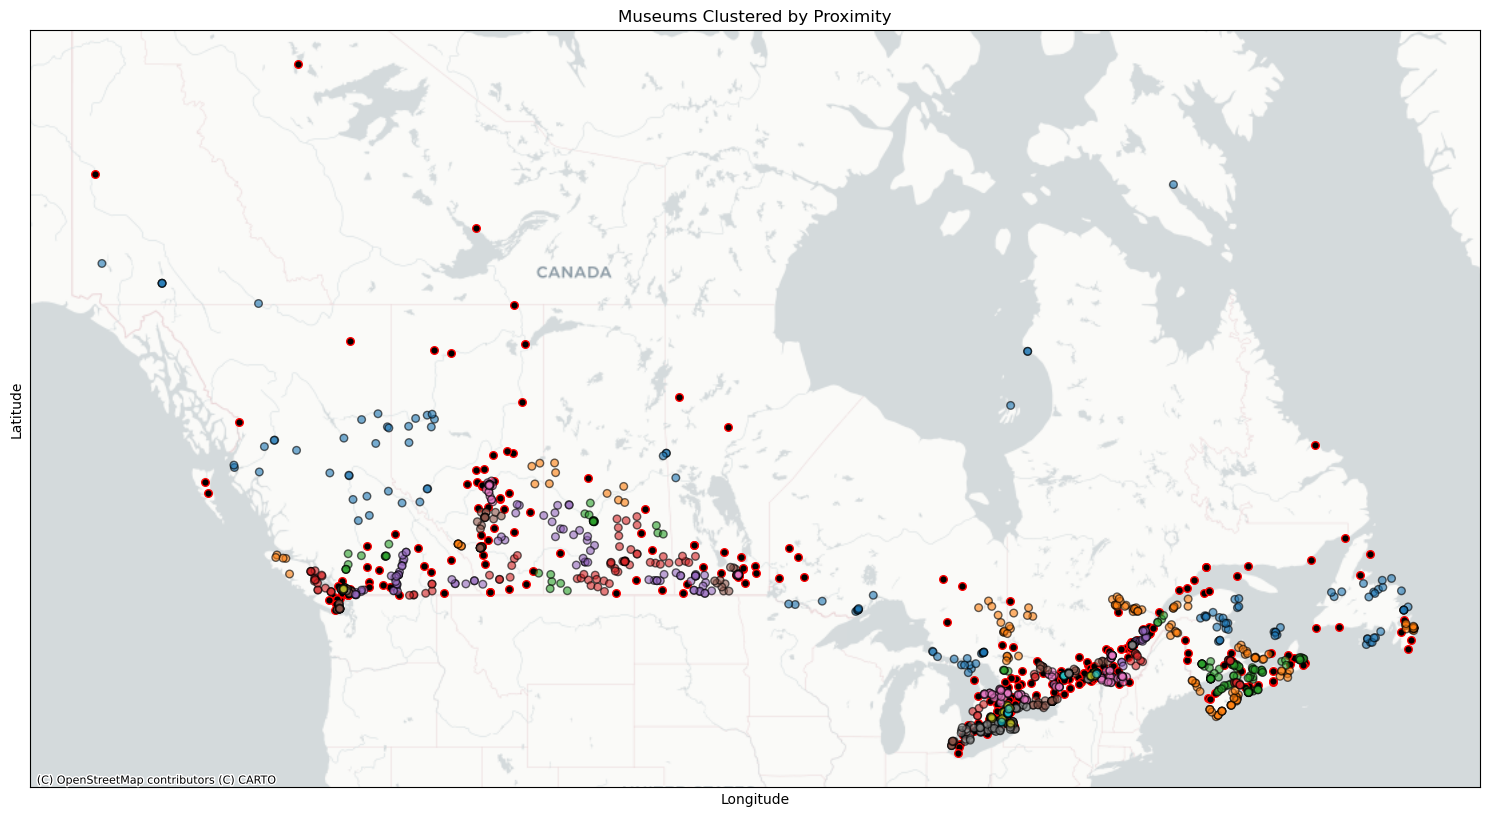

In [143]:
from pyproj import Transformer
from shapely.geometry import Point

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
gdf = gdf.copy()
gdf['geometry'] = gdf['geometry'].apply(lambda geom: Point(transformer.transform(geom.x, geom.y)))
gdf = gdf.set_crs("EPSG:3857", allow_override=True)

print(gdf.crs)
print(gdf.total_bounds)

# Create the plot
fig, ax = plt.subplots(figsize=(15, 10))

# Separate clustered from noise points
non_noise = gdf[gdf['Cluster'] != -1]
noise = gdf[gdf['Cluster'] == -1]

# Plot points
noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise', zorder=3)
non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6, zorder=3)

# Save limits before basemap resets them
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 1. Plot EVERYTHING ELSE in light grey first (The "Background")
# This includes noise (-1) and all other clusters
#background_data = gdf[gdf['Cluster'] != 30]
#background_data.plot(ax=ax, color='lightgrey', markersize=10, alpha=0.5, zorder=2, label='Other Museums')

# 2. Plot ONLY Cluster 0 in a bold color (The "Highlight")
#highlight_data = gdf[gdf['Cluster'] == 30]
#highlight_data.plot(ax=ax, color='blue', markersize=50, edgecolors='black', linewidth=1, zorder=3, label='Cluster 0')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=4, zorder=1)

# Restore data extent
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Format plot
plt.title('Museums Clustered by Proximity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()